In [29]:
# Cell 1 - Setup

#Imports
import sys
import os
import importlib
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Reload

def reload_all():
    import model.assumptions as assumptions_module
    import model.policy as policy_module
    import model.projection as projection_module
    import model.valuation as valuation_module
    import model.results as results_module
    import model.analysis.profit as profit_module

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(profit_module)

reload_all()

#Import entry points
import model.valuation as valuation
import model.analysis.profit as profit_analysis
import model.assumptions as assumptions_module
import model.policy as policy_module


# Assumptions

assumptions = assumptions_module.Assumptions(interest_rate=0.03)


#Policy

policy = policy_module.Policy(
    age=40,
    term=10,
    sum_assured=100000,
    premium=1000
)

In [30]:
# Cell 2 - Run valuation

result = valuation.value_policy(policy, assumptions, return_breakdown=True)

In [31]:
# Cell 3 - Core results

summary = {
    "PV Premiums": result.pv_premiums,
    "PV Claims": result.pv_claims,
    "Net Value": result.net_value
}

pd.Series(summary)

PV Premiums    8734.284024
PV Claims      1401.254947
Net Value      7333.029077
dtype: float64

In [32]:
# Cell 4 - Build Analysis Dataset

df = profit_analysis.build_profit_dataframe(result)
df = profit_analysis.add_profit_signature(df)

In [33]:
# Cell 5 - Profit Emergence Table

df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"
]].round(2)

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,888.72,888.72,888.72,888.72
1,1,878.48,1767.20,852.89,1741.61
2,2,867.40,2634.60,817.61,2559.22
3,3,855.43,3490.03,782.84,3342.06
4,4,842.50,4332.53,748.55,4090.61
5,5,828.53,5161.06,714.70,4805.31
6,6,813.44,5974.50,681.24,5486.55
7,7,797.15,6771.65,648.16,6134.71
8,8,779.56,7551.21,615.40,6750.10
9,9,760.59,8311.80,582.93,7333.03


In [34]:
# Cell 6 - Profit Signature

df[["t", "pv_net", "profit_pct"]].round(4)

,t,pv_net,profit_pct
0,0,888.7230,0.1212
1,1,852.8897,0.1163
2,2,817.6085,0.1115
3,3,782.8410,0.1068
4,4,748.5493,0.1021
5,5,714.6957,0.0975
6,6,681.2433,0.0929
7,7,648.1552,0.0884
8,8,615.3954,0.0839
9,9,582.9281,0.0795


In [35]:
# Cell  7 - Summary Metrics

pd.Series(profit_analysis.summary_metrics(df))

total_pv_profit      7333.029077
total_cash_profit    8311.801338
peak_profit_year        0.000000
dtype: float64

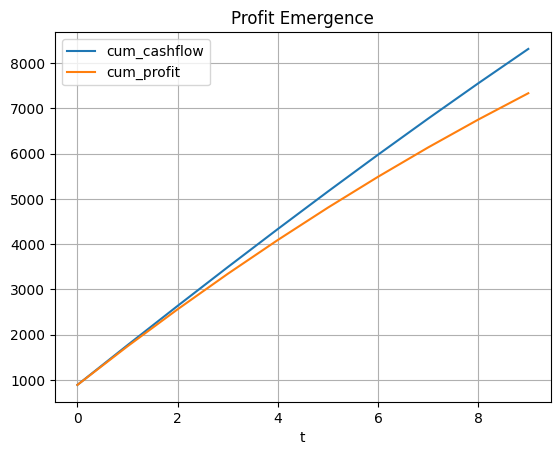

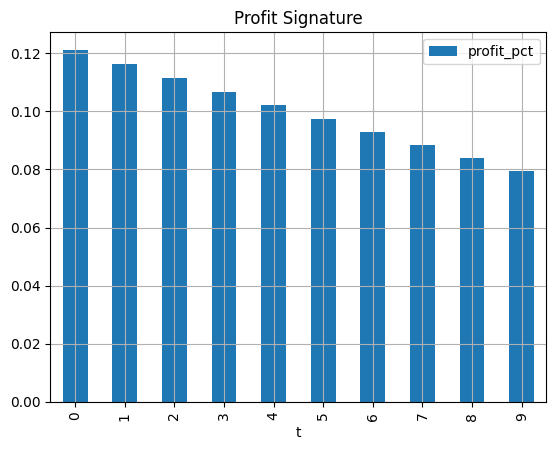

In [36]:
# Cell 8 - Visualisations

# Profit Emergence

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.grid()
plt.show()


# Profit Signature

df.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.grid()
plt.show()